<a href="https://colab.research.google.com/github/Janardan-thapaliya/Agent_Orchestration/blob/main/Blog_writer_psychology_specific.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain_community langchain_openai langgraph langchain_core python-dotenv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
# import os

# os.environ["OPENAI_API_KEY"] = ""
# os.environ["TAVILY_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""


In [ ]:
from __future__ import annotations

import operator
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

In [ ]:
# load env vars
load_dotenv()

In [ ]:
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=6,
        description="3–6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120–550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [ ]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str

In [ ]:
# 2) LLM
# -----------------------------
llm = ChatOpenAI(model="gpt-4.1-mini")

In [ ]:
# 3) Router (decide upfront)

ROUTER_SYSTEM = """You are a routing module for a psychology and human behavior blog planner.

Decide whether external research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen psychology topics where explanations rely on well-established theory
  (e.g., motivation, emotions, memory, attachment, stress, habits, neurotransmitters).

- hybrid (needs_research=true):
  Mostly evergreen concepts, but strengthened by:
  - recent studies
  - modern frameworks
  - contemporary examples (social media, work culture, dating, burnout, anxiety trends)

- open_book (needs_research=true):
  Time-sensitive or evidence-heavy topics:
  - new psychology studies
  - mental health statistics
  - cultural shifts
  - policy or diagnostic changes (DSM updates, public health guidance)

If needs_research=true:
- Output 3–10 high-signal research queries.
- Queries should be specific and scoped (avoid generic terms like just "dopamine" or "psychology").
- Prefer queries that surface:
  * meta-analyses
  * review papers
  * reputable psychology or neuroscience sources
- If the user implies recency ("new research", "recent studies"), reflect that constraint in the queries.
"""

def router_node(state: State) -> dict:

    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

In [ ]:
# 4) Research (Tavily)
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:

    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


RESEARCH_SYSTEM = """You are a research synthesizer for psychology, neuroscience, and human behavior writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Core principles:
- Prioritize accuracy, nuance, and credibility over novelty.
- Prefer sources that explain mechanisms, limitations, and context.

Source selection rules:
- Only include items with a non-empty url.
- Prefer the following sources, in order:
  1) Peer-reviewed journals (meta-analyses, review papers preferred)
  2) University or research institution publications
  3) Reputable science journalism (e.g., science desks, psychology magazines)
  4) Authoritative books or long-form essays by credentialed experts
- Avoid:
  - self-help blogs without citations
  - opinion pieces posing as science
  - overstated or sensational headlines

Metadata rules:
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
- If missing or unclear, set published_at=null. Do NOT infer or guess.
- Keep snippets concise (1–2 sentences max), focusing on:
  - the main finding
  - what was studied
  - any stated limitations or caveats

Deduplication & synthesis:
- Deduplicate strictly by URL.
- If multiple sources report the same finding:
  - Prefer the original study or the highest-quality review.
  - Exclude redundant secondary coverage unless it adds important interpretation.

Bias & framing guardrails:
- Flag (in snippet wording) when findings are:
  - correlational rather than causal
  - based on small or narrow samples
  - contested or mixed in the literature
- Do NOT overgeneralize results beyond what the source supports.
"""

def research_node(state: State) -> dict:

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 6

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}

In [ ]:
# 5) Orchestrator (Plan)

ORCH_SYSTEM = """You are a senior psychology writer and editor.
Your job is to produce a compelling, publishable-grade outline for a psychology blog post.

Audience:
- Curious, thoughtful readers (not clinicians or academics)
- Intelligent non-experts who want to understand themselves and others better

Hard requirements:
- Create 5–9 sections (tasks) appropriate for the topic.
- Each task must include:
  1) goal (1 sentence, reader-centered)
  2) 3–6 bullets that are clear, concrete, and non-overlapping
  3) target word count (150–600)

Quality bar:
- Explain complex ideas (brain chemistry, cognition, behavior) clearly without dumbing them down.
- Prefer insight over jargon; define technical terms when used.
- Tie abstract concepts to lived experience (relationships, work, stress, habits, emotions).
- Avoid pop-psych clichés and overclaims.

Narrative & depth requirements:
Ensure the overall plan includes at least 3 of the following:
- a relatable human experience or internal conflict
- explanation of underlying brain chemistry or neural mechanisms
- common misconceptions or oversimplifications
- why the behavior once made evolutionary sense
- modern mismatches (ancient brain vs modern world)
- practical reframing or reflection prompts (not prescriptive therapy)

Grounding rules:
- Mode closed_book:
  - Keep content evergreen and theory-driven.
  - Do not depend on specific studies or statistics.

- Mode hybrid:
  - Use evidence to support or contextualize claims.
  - Mark sections using fresh research as:
    requires_research=True
    requires_citations=True

- Mode open_book:
  - Set blog_kind = "research_explainer".
  - Focus on explaining findings, implications, and limitations.
  - Avoid self-help prescriptions unless explicitly requested.
  - If evidence is insufficient, state that transparently in the plan.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    return {"plan": plan}

In [ ]:
# 6) Fanout
# -----------------------------
def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [ ]:
# 7) Worker (write one section)

WORKER_SYSTEM = """You are a senior psychology writer.
Write ONE section of a psychology blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order.
- Stay close to the Target word count (±15%).
- Output ONLY the section content in Markdown.
- Start with a '## <Section Title>' heading.

Content scope:
- Write for intelligent non-experts.
- Explain mechanisms (brain, chemistry, cognition) using clear metaphors when helpful.
- Avoid clinical diagnosis, therapy instructions, or medical advice unless explicitly requested.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce specific study findings, statistics, or claims unless supported by provided Evidence URLs.
  - Cite sources using Markdown links: ([Source](URL)).
  - If a bullet requires evidence not provided, write:
    "This claim is not supported by the provided sources."

- If requires_citations == true:
  - Cite all outside-world claims using Evidence URLs.
- Evergreen conceptual explanations are allowed without citations unless flagged.

Style:
- Warm, clear, and reflective.
- Short paragraphs; occasional bullet lists for clarity.
- Use examples, internal monologue, or gentle questions to engage the reader.
- Avoid hype, moralizing, or absolute claims.
"""

def worker_node(payload: dict) -> dict:

    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [ ]:
# 8) Reducer (merge + save)
# -----------------------------
def reducer_node(state: State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}


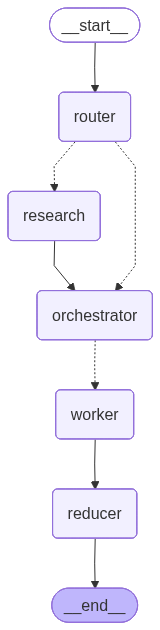

In [ ]:
# 9) Build graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [ ]:
# 10) Runner
# -----------------------------
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [ ]:
#run("Write a blog on Best Prompt Engineering Practices in 2026")
run("Self sabotage by our own brain")

/tmp/ipython-input-4283803131.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=max_results)


{'topic': 'Self sabotage by our own brain',
 'mode': 'hybrid',
 'needs_research': True,
 'queries': ['meta-analysis on cognitive and emotional mechanisms underlying self-sabotage behaviors',
  'recent studies linking neural circuitry to self-sabotage and self-defeating behaviors',
  'review articles on psychological theories explaining self-sabotage (e.g., self-handicapping, cognitive distortions)',
  'research on the role of executive function impairments in self-sabotage',
  'studies discussing the impact of anxiety and depression on self-sabotaging tendencies',
  'modern frameworks incorporating social media influence on self-sabotage',
  'research on interventions or therapeutic approaches to reduce self-sabotage'],
 'evidence': [EvidenceItem(title="Self-sabotage may reflect the brain's need for control and safety", url='https://www.news-medical.net/news/20260104/Self-sabotage-may-reflect-the-braine28099s-need-for-control-and-safety.aspx', published_at=None, snippet="Self-sabotagin

In [ ]:
"""
Psychology Blog Generator with Lead + Editorial Agents
"""

# -----------------------------
# Models (intentional split)
# -----------------------------
ROUTER_LLM = ChatOpenAI(model="gpt-4.1-mini")
RESEARCH_LLM = ChatOpenAI(model="gpt-4.1-mini")
ORCH_LLM = ChatOpenAI(model="gpt-4.1")
LEAD_LLM = ChatOpenAI(model="gpt-4.1")
WORKER_LLM = ChatOpenAI(model="gpt-4.1-mini")
EDITOR_LLM = ChatOpenAI(model="gpt-4.1")

# -----------------------------
# Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str
    goal: str
    bullets: List[str]
    target_words: int
    tags: List[str] = []
    requires_research: bool = False
    requires_citations: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "research_explainer"] = "explainer"
    constraints: List[str]
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str]


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem]


class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    lead_section: Optional[str]
    sections: Annotated[List[tuple[int, str]], operator.add]
    final: str


ROUTER_SYSTEM = """You are a routing module for a psychology and human behavior blog planner.

Decide whether external research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen psychology topics where explanations rely on well-established theory
  (e.g., motivation, emotions, memory, attachment, stress, habits, neurotransmitters).

- hybrid (needs_research=true):
  Mostly evergreen concepts, but strengthened by:
  - recent studies
  - modern frameworks
  - contemporary examples (social media, work culture, dating, burnout, anxiety trends)

- open_book (needs_research=true):
  Time-sensitive or evidence-heavy topics:
  - new psychology studies
  - mental health statistics
  - cultural shifts
  - policy or diagnostic changes (DSM updates, public health guidance)

If needs_research=true:
- Output 3–10 high-signal research queries.
- Queries should be specific and scoped (avoid generic terms like just "dopamine" or "psychology").
- Prefer queries that surface:
  * meta-analyses
  * review papers
  * reputable psychology or neuroscience sources
- If the user implies recency ("new research", "recent studies"), reflect that constraint in the queries.
"""

def router_node(state: State):
    decision = ROUTER_LLM.with_structured_output(RouterDecision).invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {state['topic']}")
        ]
    )
    return decision.model_dump()

def route_next(state: State):
    return "research" if state["needs_research"] else "orchestrator"


RESEARCH_SYSTEM = """You are a research synthesizer for psychology, neuroscience, and human behavior writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Core principles:
- Prioritize accuracy, nuance, and credibility over novelty.
- Prefer sources that explain mechanisms, limitations, and context.

Source selection rules:
- Only include items with a non-empty url.
- Prefer the following sources, in order:
  1) Peer-reviewed journals (meta-analyses, review papers preferred)
  2) University or research institution publications
  3) Reputable science journalism (e.g., science desks, psychology magazines)
  4) Authoritative books or long-form essays by credentialed experts
- Avoid:
  - self-help blogs without citations
  - opinion pieces posing as science
  - overstated or sensational headlines

Metadata rules:
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
- If missing or unclear, set published_at=null. Do NOT infer or guess.
- Keep snippets concise (1–2 sentences max), focusing on:
  - the main finding
  - what was studied
  - any stated limitations or caveats

Deduplication & synthesis:
- Deduplicate strictly by URL.
- If multiple sources report the same finding:
  - Prefer the original study or the highest-quality review.
  - Exclude redundant secondary coverage unless it adds important interpretation.

Bias & framing guardrails:
- Flag (in snippet wording) when findings are:
  - correlational rather than causal
  - based on small or narrow samples
  - contested or mixed in the literature
- Do NOT overgeneralize results beyond what the source supports.
"""

def tavily_search(query, max_results=5):
    tool = TavilySearchResults(max_results=max_results)
    return tool.invoke({"query": query}) or []

def research_node(state: State):
    raw = []
    for q in state["queries"]:
        raw.extend(tavily_search(q))
    if not raw:
        return {"evidence": []}

    pack = RESEARCH_LLM.with_structured_output(EvidencePack).invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=str(raw))
        ]
    )

    dedup = {e.url: e for e in pack.evidence if e.url}
    return {"evidence": list(dedup.values())}


ORCH_SYSTEM = """You are a senior psychology writer and editor.
Your job is to produce a compelling, publishable-grade outline for a psychology blog post.

Audience:
- Curious, thoughtful readers (not clinicians or academics)
- Intelligent non-experts who want to understand themselves and others better

Hard requirements:
- Create 5–9 sections (tasks) appropriate for the topic.
- Each task must include:
  1) goal (1 sentence, reader-centered)
  2) 3–6 bullets that are clear, concrete, and non-overlapping
  3) target word count (150–600)

Structural constraint:
- Each section must cover a distinct conceptual layer.
- Avoid assigning multiple sections the same role (e.g., multiple overviews or multiple explanations of the same mechanism).
- Assume sections will be written in parallel; design them to build on each other rather than repeat.

Quality bar:
- Explain complex ideas (brain chemistry, cognition, behavior) clearly without dumbing them down.
- Prefer insight over jargon; define technical terms when used.
- Tie abstract concepts to lived experience (relationships, work, stress, habits, emotions).
- Avoid pop-psych clichés and overclaims.

Narrative & depth requirements:
Ensure the overall plan includes at least 3 of the following:
- a relatable human experience or internal conflict
- explanation of underlying brain chemistry or neural mechanisms
- common misconceptions or oversimplifications
- why the behavior once made evolutionary sense
- modern mismatches (ancient brain vs modern world)
- practical reframing or reflection prompts (not prescriptive therapy)

Grounding rules:
- Mode closed_book:
  - Keep content evergreen and theory-driven.
  - Do not depend on specific studies or statistics.

- Mode hybrid:
  - Use evidence to support or contextualize claims.
  - Mark sections using fresh research as:
    requires_research=True
    requires_citations=True

- Mode open_book:
  - Set blog_kind = "research_explainer".
  - Focus on explaining findings, implications, and limitations.
  - Avoid self-help prescriptions unless explicitly requested.
  - If evidence is insufficient, state that transparently in the plan.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State):
    plan = ORCH_LLM.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(content=f"Topic: {state['topic']}\nMode: {state['mode']}")
        ]
    )
    return {"plan": plan}

LEAD_SYSTEM = """You are a senior long-form psychology writer.
You are writing the opening section of a reflective psychology essay.

Purpose of this section:
- Establish voice, tone, and pacing for the entire article.
- Frame the central human tension behind the topic.
- Signal depth and credibility without explaining everything yet.

Hard constraints:
- Write ONE opening section in Markdown.
- Start with a '## Introduction' heading.
- Target 350–550 words.
- Do NOT summarize the entire article.
- Do NOT preview every section explicitly.

Content requirements:
- Begin with a concrete, relatable human experience or internal conflict.
- Gradually reveal the psychological theme behind it.
- Introduce key concepts lightly, without definitions or jargon-heavy explanations.
- Maintain narrative momentum rather than instructional clarity.

Style constraints:
- Do NOT use bold text.
- Use italics sparingly.
- Avoid lists unless absolutely necessary.
- Do NOT end with a direct question.
- Write with calm authority and restraint.

Tone:
- Thoughtful, grounded, and observant.
- Write as if you are noticing something true rather than explaining a concept.
"""

def lead_node(state: State):
    lead = LEAD_LLM.invoke(
        [
            SystemMessage(content=LEAD_SYSTEM),
            HumanMessage(content=f"Topic: {state['topic']}\nTitle: {state['plan'].blog_title}")
        ]
    ).content.strip()
    return {"lead_section": lead}


WORKER_SYSTEM = """You are a senior psychology writer contributing one section to a long-form essay.

Your role:
- Write ONE section that fits seamlessly into a larger article.
- Assume other sections exist and will cover adjacent ideas.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order.
- Stay close to the Target word count (±15%).
- Output ONLY the section content in Markdown.
- Start with a '## <Section Title>' heading.

Global coherence rules:
- Focus strictly on the concepts assigned in this section.
- Do NOT restate:
  * the article’s main thesis,
  * basic definitions likely covered earlier,
  * background context unless explicitly required by a bullet.
- If a concept overlaps with another section, acknowledge it briefly and move forward without re-explaining it.

Section structure requirement:
- Begin with a short, concise summary paragraph (2–3 sentences):
  * no metaphors,
  * no examples,
  * just the core idea of the section.
- Follow with a deeper exploration that:
  * explains causes and mechanisms,
  * connects ideas through cause and effect,
  * elaborates on what, why, and how,
  * uses examples and analogies naturally,
  * explores limits, trade-offs, or edge cases where relevant.

Content scope:
- Write for intelligent non-experts.
- Explain brain chemistry and cognition clearly, using metaphors only when they add clarity.
- Avoid clinical diagnosis, therapy instructions, or medical advice unless explicitly requested.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce specific studies, statistics, or claims unless supported by provided Evidence URLs.
  - Cite sources using Markdown links: ([Source](URL)).
  - If a bullet requires evidence not provided, state that plainly.
- If requires_citations == true:
  - Cite all outside-world claims using Evidence URLs.
- Evergreen conceptual reasoning does not require citations unless flagged.

Formatting and style constraints:
- Do NOT use bold text.
- Use italics sparingly and only for subtle emphasis or definitions.
- Avoid dash-led bullet lists unless strictly necessary.
- Prefer short, flowing paragraphs over lists.
- Vary sentence length and rhythm; avoid symmetrical or mechanical phrasing.

Flow constraint:
- Do NOT end the section with explicit questions directed at the reader.
- Close with an observation, implication, or natural transition into the next idea.

Tone:
- Calm, confident, and reflective.
- Write as if you are naming something the reader has already felt but never articulated.
- Avoid hype, moralizing, or prescriptive self-help language.
"""

def worker_node(payload):
    task = Task(**payload["task"])
    lead = payload["lead_section"]

    bullets = "\n".join(f"{i+1}. {b}" for i, b in enumerate(task.bullets))

    section = WORKER_LLM.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Lead section (style anchor):\n{lead}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:\n{bullets}"
                )
            )
        ]
    ).content.strip()

    return {"sections": [(task.id, section)]}

# -----------------------------
# Reducer
# -----------------------------
def reducer_node(state: State):
    plan = state["plan"]
    sections = [s for _, s in sorted(state["sections"], key=lambda x: x[0])]

    body = "\n\n".join(sections).replace("\n\n\n", "\n\n")
    final = f"# {plan.blog_title}\n\n{state['lead_section']}\n\n{body}"

    return {"final": final}


EDITOR_SYSTEM = """You are a senior editor refining a long-form psychology essay.

Your role:
- Improve flow, clarity, and cohesion.
- Preserve the author’s voice.
- Do NOT add new ideas, metaphors, or evidence.

Editorial tasks:
- Remove or condense repetitive explanations.
- Smooth abrupt transitions between sections.
- Eliminate visible AI patterns, including:
  * overuse of em dashes or dash-bridged clauses,
  * sentence structures that rely on punctuation instead of syntax,
  * symmetrical or formulaic phrasing.

Dash handling rule:
- Actively reduce the use of em dashes and dash-like constructions.
- When a dash connects an explanation or clarification:
  * rewrite the sentence using commas, conjunctions, or sentence separation,
  * prefer grammatical integration over punctuation-driven emphasis.
- Preserve meaning while making the sentence read more naturally.

Hard constraints:
- Do NOT rewrite everything.
- Do NOT change the meaning of any section.
- Do NOT add or remove headings.
- Do NOT introduce questions at section endings.

Formatting constraints:
- No bold text.
- Do not introduce new italics.
- Preserve existing Markdown structure.

Output:
- Return the full revised Markdown document only.
"""


def editor_node(state: State):
    edited = EDITOR_LLM.invoke(
        [
            SystemMessage(content=EDITOR_SYSTEM),
            HumanMessage(content=state["final"])
        ]
    ).content.strip()

    filename = f"{state['plan'].blog_title}.md"
    Path(filename).write_text(edited, encoding="utf-8")

    return {"final": edited}

# -----------------------------
# Graph
# -----------------------------
g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("lead", lead_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)
g.add_node("editor", editor_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")
g.add_edge("orchestrator", "lead")

g.add_conditional_edges(
    "lead",
    lambda s: [
        Send(
            "worker",
            {
                "task": t.model_dump(),
                "lead_section": s["lead_section"]
            }
        )
        for t in s["plan"].tasks
    ],
    ["worker"]
)

g.add_edge("worker", "reducer")
g.add_edge("reducer", "editor")
g.add_edge("editor", END)

app = g.compile()

# -----------------------------
# Runner
# -----------------------------
def run(topic: str):
    return app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "lead_section": None,
            "sections": [],
            "final": "",
        }
    )

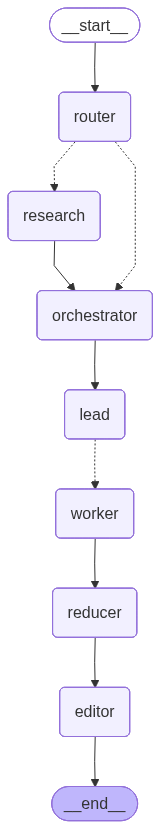

In [ ]:
app

In [ ]:
# Example
run("How having clear step-by-step approach or idea to a task improves motivation.")

{'topic': 'How having clear step-by-step approach or idea to a task improves motivation.',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': [],
 'evidence': [],
 'plan': Plan(blog_title='How a Step-by-Step Approach Fuels Motivation: The Psychology Behind Clarity and Action', audience='Curious, thoughtful readers seeking insights into everyday motivation', tone='Engaging, insightful, clear', blog_kind='explainer', constraints=['5–9 distinct conceptual sections', 'No overlapping roles between sections; each explores a different layer', 'Technical terms explained without jargon', 'At least 3: relatable human experience, explanation of neural mechanisms, common misconceptions, evolutionary reasons, modern mismatches, practical reflection/reframing prompts'], tasks=[Task(id=1, title='The Paradox of Motivation: Why Ambition Stalls Without a Map', goal='Highlight a familiar internal conflict: feeling motivated in theory but stuck in practice.', bullets=['Describe the common exper